In [1]:
import numpy as np 
import sympy as sp 
import scipy 
import matplotlib.pyplot as plt 



# Question 1

In [2]:
#1
t = sp.Symbol('t')
theta = sp.Function('theta')(t)
x = sp.Function('x')(t)
y = sp.Function('y')(t)
alpha_1 = sp.Function('alpha_1')(t)
alpha_2 = sp.Function('alpha_2')(t)
L = sp.Symbol('L')

CoM_2 = sp.Matrix([[sp.cos(theta), -sp.sin(theta), x], [sp.sin(theta), sp.cos(theta), y], [0, 0, 1]])

C2_J2 = sp.Matrix([[1, 0, L/2], [0, 1, 0], [0, 0, 1]])
J2_rot = sp.Matrix([[sp.cos(alpha_2), -sp.sin(alpha_2), 0], [sp.sin(alpha_2), sp.cos(alpha_2), 0], [0,0,1]])
J2_C3 = sp.Matrix([[1, 0, L/2], [0, 1, 0], [0, 0, 1]])

CoM_3 = CoM_2 * C2_J2 * J2_rot * J2_C3 

C2_J1 = sp.Matrix([[1, 0, -L/2], [0, 1, 0], [0, 0, 1]])
J1_rot = sp.Matrix([[sp.cos(alpha_1), -sp.sin(alpha_1), 0], [sp.sin(alpha_1), sp.cos(alpha_1), 0], [0,0,1]])
J1_C1 = sp.Matrix([[1, 0, -L/2], [0, 1, 0], [0, 0, 1]])

CoM_1 = CoM_2 * C2_J1 * J1_rot * J1_C1 

CoM_1.simplify()
CoM_3.simplify()

CoM_1


Matrix([
[cos(alpha_1(t) + theta(t)), -sin(alpha_1(t) + theta(t)), -L*cos(alpha_1(t) + theta(t))/2 - L*cos(theta(t))/2 + x(t)],
[sin(alpha_1(t) + theta(t)),  cos(alpha_1(t) + theta(t)), -L*sin(alpha_1(t) + theta(t))/2 - L*sin(theta(t))/2 + y(t)],
[                         0,                           0,                                                          1]])

In [3]:
CoM_2


Matrix([
[cos(theta(t)), -sin(theta(t)), x(t)],
[sin(theta(t)),  cos(theta(t)), y(t)],
[            0,              0,    1]])

In [4]:
CoM_3

Matrix([
[cos(alpha_2(t) + theta(t)), -sin(alpha_2(t) + theta(t)), L*cos(alpha_2(t) + theta(t))/2 + L*cos(theta(t))/2 + x(t)],
[sin(alpha_2(t) + theta(t)),  cos(alpha_2(t) + theta(t)), L*sin(alpha_2(t) + theta(t))/2 + L*sin(theta(t))/2 + y(t)],
[                         0,                           0,                                                         1]])

In [5]:
#2 

def inv(T):
    R = T[0:2, 0:2]
    p = T[0:2, 2]

    T_inv = sp.Matrix.zeros(3,3)
    T_inv[0:2, 0:2] = R.T 
    T_inv[0:2, 2] = -R.T * p 
    return T_inv 


Vb_1 = inv(CoM_1) * CoM_1.diff(t)
Vb_2 = inv(CoM_2) * CoM_2.diff(t)
Vb_3 = inv(CoM_3) * CoM_3.diff(t)

Vb_1.simplify()
Vb_2.simplify()
Vb_3.simplify()

Vb_1

Matrix([
[                                                  0, -Derivative(alpha_1(t), t) - Derivative(theta(t), t),                                                               -L*sin(alpha_1(t))*Derivative(theta(t), t)/2 + sin(alpha_1(t) + theta(t))*Derivative(y(t), t) + cos(alpha_1(t) + theta(t))*Derivative(x(t), t)],
[Derivative(alpha_1(t), t) + Derivative(theta(t), t),                                                    0, -L*cos(alpha_1(t))*Derivative(theta(t), t)/2 - L*Derivative(alpha_1(t), t)/2 - L*Derivative(theta(t), t)/2 - sin(alpha_1(t) + theta(t))*Derivative(x(t), t) + cos(alpha_1(t) + theta(t))*Derivative(y(t), t)],
[                                                  0,                                                    0,                                                                                                                                                                                                            0]])

In [6]:
Vb_2

Matrix([
[                      0, -Derivative(theta(t), t),  sin(theta(t))*Derivative(y(t), t) + cos(theta(t))*Derivative(x(t), t)],
[Derivative(theta(t), t),                        0, -sin(theta(t))*Derivative(x(t), t) + cos(theta(t))*Derivative(y(t), t)],
[                      0,                        0,                                                                      0]])

In [7]:
Vb_3

Matrix([
[                                                  0, -Derivative(alpha_2(t), t) - Derivative(theta(t), t),                                                               L*sin(alpha_2(t))*Derivative(theta(t), t)/2 + sin(alpha_2(t) + theta(t))*Derivative(y(t), t) + cos(alpha_2(t) + theta(t))*Derivative(x(t), t)],
[Derivative(alpha_2(t), t) + Derivative(theta(t), t),                                                    0, L*cos(alpha_2(t))*Derivative(theta(t), t)/2 + L*Derivative(alpha_2(t), t)/2 + L*Derivative(theta(t), t)/2 - sin(alpha_2(t) + theta(t))*Derivative(x(t), t) + cos(alpha_2(t) + theta(t))*Derivative(y(t), t)],
[                                                  0,                                                    0,                                                                                                                                                                                                           0]])

In [8]:
#3 
q_dot = sp.Matrix([x.diff(t), y.diff(t), theta.diff(t), alpha_1.diff(t), alpha_2.diff(t)])

def three_vector(V_hat):
    return sp.Matrix([V_hat[1,0], V_hat[0,2], V_hat[1,2]])

v1_vec = three_vector(Vb_1)
v2_vec = three_vector(Vb_2)
v3_vec = three_vector(Vb_3)

Jb1 = v1_vec.jacobian(q_dot)
Jb2 = v2_vec.jacobian(q_dot)
Jb3 = v3_vec.jacobian(q_dot)

Jb1.simplify()
Jb2.simplify()
Jb3.simplify()

Jb1

Matrix([
[                          0,                          0,                          1,    1, 0],
[ cos(alpha_1(t) + theta(t)), sin(alpha_1(t) + theta(t)),       -L*sin(alpha_1(t))/2,    0, 0],
[-sin(alpha_1(t) + theta(t)), cos(alpha_1(t) + theta(t)), -L*(cos(alpha_1(t)) + 1)/2, -L/2, 0]])

In [9]:
Jb2

Matrix([
[             0,             0, 1, 0, 0],
[ cos(theta(t)), sin(theta(t)), 0, 0, 0],
[-sin(theta(t)), cos(theta(t)), 0, 0, 0]])

In [10]:
Jb3

Matrix([
[                          0,                          0,                         1, 0,   1],
[ cos(alpha_2(t) + theta(t)), sin(alpha_2(t) + theta(t)),       L*sin(alpha_2(t))/2, 0,   0],
[-sin(alpha_2(t) + theta(t)), cos(alpha_2(t) + theta(t)), L*(cos(alpha_2(t)) + 1)/2, 0, L/2]])

In [11]:
#4 

k = sp.Symbol('k')
def body_wrench(twist):
    B = sp.Matrix([[2/3*k*L**3, 0 , 0], [0, k*L, 0], [0, 0, 2*k*L]])
    return -B * twist

Fb1 = body_wrench(v1_vec)
Fb2 = body_wrench(v2_vec)
Fb3 = body_wrench(v3_vec)

Fb1.simplify() 
Fb2.simplify()
Fb3.simplify()

Fb1

Matrix([
[                                                                                                                                -0.666666666666667*L**3*k*(Derivative(alpha_1(t), t) + Derivative(theta(t), t))],
[                                                        L*k*(L*sin(alpha_1(t))*Derivative(theta(t), t) - 2*sin(alpha_1(t) + theta(t))*Derivative(y(t), t) - 2*cos(alpha_1(t) + theta(t))*Derivative(x(t), t))/2],
[L*k*(L*cos(alpha_1(t))*Derivative(theta(t), t) + L*Derivative(alpha_1(t), t) + L*Derivative(theta(t), t) + 2*sin(alpha_1(t) + theta(t))*Derivative(x(t), t) - 2*cos(alpha_1(t) + theta(t))*Derivative(y(t), t))]])

In [12]:
Fb2

Matrix([
[                            -0.666666666666667*L**3*k*Derivative(theta(t), t)],
[ -L*k*(sin(theta(t))*Derivative(y(t), t) + cos(theta(t))*Derivative(x(t), t))],
[2*L*k*(sin(theta(t))*Derivative(x(t), t) - cos(theta(t))*Derivative(y(t), t))]])

In [13]:
Fb3

Matrix([
[                                                                                                                                 -0.666666666666667*L**3*k*(Derivative(alpha_2(t), t) + Derivative(theta(t), t))],
[                                                        -L*k*(L*sin(alpha_2(t))*Derivative(theta(t), t) + 2*sin(alpha_2(t) + theta(t))*Derivative(y(t), t) + 2*cos(alpha_2(t) + theta(t))*Derivative(x(t), t))/2],
[L*k*(-L*cos(alpha_2(t))*Derivative(theta(t), t) - L*Derivative(alpha_2(t), t) - L*Derivative(theta(t), t) + 2*sin(alpha_2(t) + theta(t))*Derivative(x(t), t) - 2*cos(alpha_2(t) + theta(t))*Derivative(y(t), t))]])

In [14]:
#5
tau1 = -(Jb1.T * Fb1 + Jb2.T * Fb2 + Jb3.T * Fb3) 
tau1.simplify()

B = sp.Matrix([[2/3*k*L**3, 0 , 0], [0, k*L, 0], [0, 0, 2*k*L]])

A = (Jb1.T*B*Jb1) + (Jb2.T*B*Jb2) + (Jb3.T*B*Jb3)
A.simplify()

tau = A*q_dot
tau.simplify()


In [15]:
tau1

Matrix([
[                                                                  L*k*((-L*sin(alpha_1(t))*Derivative(theta(t), t) + 2*sin(alpha_1(t) + theta(t))*Derivative(y(t), t) + 2*cos(alpha_1(t) + theta(t))*Derivative(x(t), t))*cos(alpha_1(t) + theta(t)) + (L*sin(alpha_2(t))*Derivative(theta(t), t) + 2*sin(alpha_2(t) + theta(t))*Derivative(y(t), t) + 2*cos(alpha_2(t) + theta(t))*Derivative(x(t), t))*cos(alpha_2(t) + theta(t)) + 2*(L*cos(alpha_1(t))*Derivative(theta(t), t) + L*Derivative(alpha_1(t), t) + L*Derivative(theta(t), t) + 2*sin(alpha_1(t) + theta(t))*Derivative(x(t), t) - 2*cos(alpha_1(t) + theta(t))*Derivative(y(t), t))*sin(alpha_1(t) + theta(t)) - 2*(L*cos(alpha_2(t))*Derivative(theta(t), t) + L*Derivative(alpha_2(t), t) + L*Derivative(theta(t), t) - 2*sin(alpha_2(t) + theta(t))*Derivative(x(t), t) + 2*cos(alpha_2(t) + theta(t))*Derivative(y(t), t))*sin(alpha_2(t) + theta(t)) - sin(2*theta(t))*Derivative(y(t), t) - cos(2*theta(t))*Derivative(x(t), t) + 3*Derivative(x(t), t))

In [16]:
#6 
A11 = A[0:3, 0:3]
A12 = A[0:3, 3:5]

#cannot print or run recon_matrix as it is computationally expensive and will not terminate 
# recon_matrix = -A11.inv()*A12 

In [17]:
A11 

Matrix([
[                                          L*k*(-cos(2*alpha_1(t) + 2*theta(t)) - cos(2*alpha_2(t) + 2*theta(t)) - cos(2*theta(t)) + 9)/2,                                                -L*k*(sin(2*alpha_1(t) + 2*theta(t)) + sin(2*alpha_2(t) + 2*theta(t)) + sin(2*theta(t)))/2,  L**2*k*(2*sin(alpha_1(t) + theta(t)) + sin(2*alpha_1(t) + theta(t))/2 - 2*sin(alpha_2(t) + theta(t)) - sin(2*alpha_2(t) + theta(t))/2)/2],
[                                              -L*k*(sin(2*alpha_1(t) + 2*theta(t)) + sin(2*alpha_2(t) + 2*theta(t)) + sin(2*theta(t)))/2,                                             L*k*(cos(2*alpha_1(t) + 2*theta(t)) + cos(2*alpha_2(t) + 2*theta(t)) + cos(2*theta(t)) + 9)/2, L**2*k*(-2*cos(alpha_1(t) + theta(t)) - cos(2*alpha_1(t) + theta(t))/2 + 2*cos(alpha_2(t) + theta(t)) + cos(2*alpha_2(t) + theta(t))/2)/2],
[L**2*k*(2*sin(alpha_1(t) + theta(t)) + sin(2*alpha_1(t) + theta(t))/2 - 2*sin(alpha_2(t) + theta(t)) - sin(2*alpha_2(t) + theta(t))/2)/2, L**2*k*(-2*cos(a

In [18]:
A12 

Matrix([
[            L**2*k*sin(alpha_1(t) + theta(t)),            -L**2*k*sin(alpha_2(t) + theta(t))],
[           -L**2*k*cos(alpha_1(t) + theta(t)),             L**2*k*cos(alpha_2(t) + theta(t))],
[L**3*k*(cos(alpha_1(t)) + 2.33333333333333)/2, L**3*k*(cos(alpha_2(t)) + 2.33333333333333)/2]])

In [19]:
#cannot print or run recon_matrix as it is computationally expensive and will not terminate 

#recon_matrix

#instead solving it numerically 
var = [theta, alpha_1, alpha_2, k, L]
A11_func = sp.lambdify(var, A11, 'numpy')
A12_func = sp.lambdify(var, A12, 'numpy')

def recon_matrix_num(theta, a1, a2, k,L):
    a11 = A11_func(theta, a1, a2, k, L)
    a12 = A12_func(theta, a1, a2, k, L)
    
    return -np.linalg.solve(a11, a12)


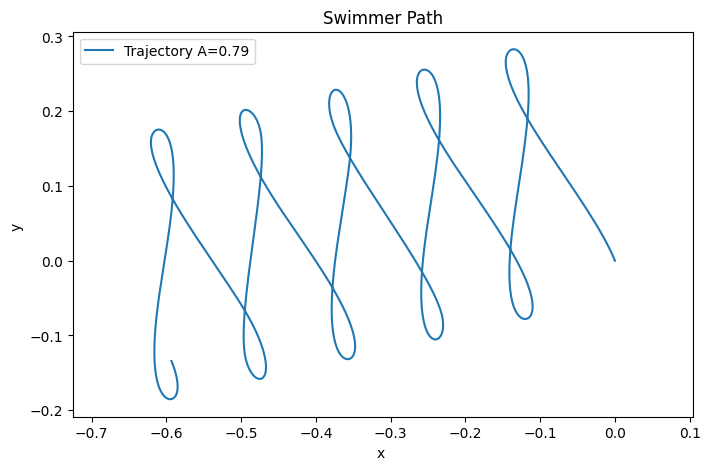

In [20]:
#7 
k = 1 
L = 1

A = np.pi/4 
phi = np.pi/2

def swimmer(t, q):
    theta = q[2]
    a1 = A* np.sin(2 * np.pi * t)
    a2 = A* np.sin(2 * np.pi*t + phi)

    a1_dot = A* (2*np.pi) * np.cos(2 * np.pi * t)
    a2_dot = A* (2*np.pi) * np.cos(2 * np.pi * t + phi)

    alpha_dot = np.array([a1_dot, a2_dot])
    recon = recon_matrix_num(theta, a1, a2, k, L)

    result = recon @ alpha_dot
    return np.array(result).flatten()

q0 = [0,0,0]
tspan = (0,5)
t_eval = np.linspace(0,5,500)

sol = scipy.integrate.solve_ivp(swimmer, tspan, q0, t_eval=t_eval)

plt.figure(figsize=(8,5))
plt.plot(sol.y[0], sol.y[1], label=f'Trajectory A={A:.2f}')
plt.axis('equal')
plt.xlabel('x ')
plt.ylabel('y ')
plt.title('Swimmer Path')
plt.legend()
plt.show()

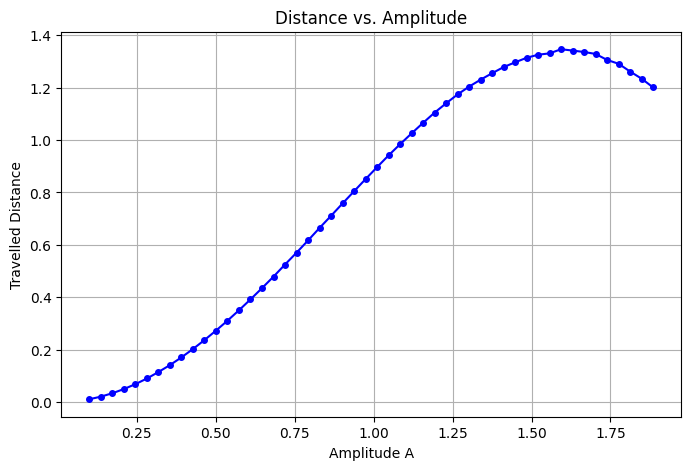

In [21]:
#8 


def swimmer(t, q,A, phi, k, L):
    theta = q[2]
    a1 = A* np.sin(2 * np.pi * t)
    a2 = A* np.sin(2 * np.pi*t + phi)

    a1_dot = A* (2*np.pi) * np.cos(2 * np.pi * t)
    a2_dot = A* (2*np.pi) * np.cos(2 * np.pi * t + phi)

    alpha_dot = np.array([a1_dot, a2_dot])
    recon = recon_matrix_num(theta, a1, a2, k, L)

    result = recon @ alpha_dot
    return np.array(result).flatten()


total_A = np.linspace(0.1, 1.2 * np.pi/2, 50)
distances = [] 

for a in total_A:
    sol = scipy.integrate.solve_ivp(swimmer, tspan, q0, t_eval = [tspan[1]], args=(a, phi, k, L))
    xf = sol.y[0,-1]
    yf = sol.y[1,-1]

    distances.append(np.sqrt(xf**2 + yf**2)) 

plt.figure(figsize=(8, 5))
plt.plot(total_A, distances, 'b-o', markersize=4)
plt.xlabel('Amplitude A')
plt.ylabel('Travelled Distance')
plt.title('Distance vs. Amplitude')
plt.grid(True)
plt.show()

# Question 2

In [22]:
#1
def wrench_from_twist(twist, f_long, f_perp, L):
    wz, vx, vy = twist 

    if vx > 0: 
        fx = -f_long 
    elif vx < 0: 
        fx = 2 * f_long 
    else: 
        fx = 0


    if vy != 0: 
        fy = -f_perp * np.sign(vy)
    else: 
        fy = 0

    if wz != 0: 
        mz = -(f_perp * (L**2)/12) *np.sign(wz)
    else: 
        mz = 0 

    return np.array([mz, fx, fy])

    


In [23]:
#2 

x_s, y_s, th_s, a1_s, a2_s = sp.symbols('x y theta alpha_1 alpha_2')

clean_subs = {x: x_s, y: y_s, theta: th_s, alpha_1: a1_s, alpha_2: a2_s}


args = ('x', 'y', 'theta', 'alpha_1', 'alpha_2', 'L')
J1_func = sp.lambdify(args, Jb1.subs(clean_subs), 'numpy')
J2_func = sp.lambdify(args, Jb2.subs(clean_subs), 'numpy')
J3_func = sp.lambdify(args, Jb3.subs(clean_subs), 'numpy')


def force_from_var(config_vars, q_shape, dq_shape, f_long, f_perp, L):

    dq_full = np.concatenate([config_vars, dq_shape])
    J1 = J1_func(0,0,0,q_shape[0], q_shape[1], L)
    J2 = J2_func(0,0,0,q_shape[0], q_shape[1], L)
    J3 = J3_func(0,0,0,q_shape[0], q_shape[1], L)

    V1 = J1 @ dq_full 
    V2 = J2 @ dq_full 
    V3 = J3 @ dq_full

    w1 = wrench_from_twist(V1, f_long, f_perp, L)
    w2 = wrench_from_twist(V2, f_long, f_perp, L)
    w3 = wrench_from_twist(V3, f_long, f_perp, L)

    net_force = (J1.T @ w1)[:3] + (J2.T @ w2)[:3] + (J3.T @ w3)[:3]

    return net_force 

In [24]:
#3 
f_long = 1.0 
f_perp = 10.0 
L = 1.0

q_shape = np.random.uniform(-np.pi/4, np.pi/4,2)
dq_shape = np.random.uniform(-1.0,1.0,2)

v_guess = np.array([0.1,0.1,0.1])

soln = scipy.optimize.fsolve(force_from_var, v_guess, args = (q_shape, dq_shape, f_long, f_perp, L))

print("Random Configuration (alpha1, alpha2):", q_shape)
print("Random Joint Velocities (da1, da2):", dq_shape)
print(f"Calculated Swimmer Velocity (V): \n vx: {soln[0]:.4f} \n vy: {soln[1]:.4f} \n wz: {soln[2]:.4f}")

Random Configuration (alpha1, alpha2): [-0.05602912  0.43425172]
Random Joint Velocities (da1, da2): [-0.80020104 -0.84270408]
Calculated Swimmer Velocity (V): 
 vx: 0.1368 
 vy: -0.0293 
 wz: 0.0847


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:177: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


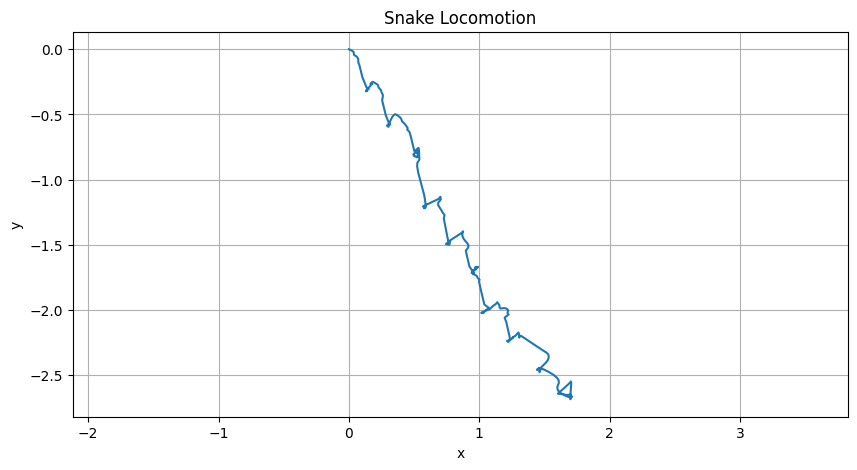

In [25]:
#4 
def snake_dynamics(t, state, f_long, f_perp,L):
    x,y,theta, a1, a2 = state 
    A = 0.5
    w = 2*np.pi 

    a1_t = A*np.cos(w*t)
    a2_t = A*np.sin(w*t)
    da1_dt = -A*w* np.sin(w*t)
    da2_dt = A*w*np.cos(w*t)

    q_shape = [a1_t, a2_t]
    dq_shape = [da1_dt, da2_dt]

    v_guess = [0.1,0.1,0.1]
    soln = scipy.optimize.fsolve(force_from_var, v_guess, args=(q_shape, dq_shape, f_long, f_perp, L))

    return np.concatenate([soln, dq_shape])

t_span = (0, 10)
t_eval = np.linspace(0, 10, 500)
initial_state = [0, 0, 0, 0.5, 0]
sol = scipy.integrate.solve_ivp(snake_dynamics, t_span, initial_state, t_eval=t_eval, args=(1.0, 10.0, 1.0))
x_path = sol.y[0]
y_path = sol.y[1]

plt.figure(figsize=(10, 5))
plt.plot(x_path, y_path, label='Path of Snake')
plt.title("Snake Locomotion")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.grid(True)
plt.show()